# PTB-XL — Data Processing Pipeline

Applies every decision made in the EDA notebook to produce clean, balanced, split `.npy` files ready for Phase 1 training.

## Pipeline summary
| Step | What happens |
|------|--------------|
| 1 | Load metadata → extract diagnostic superclass (`diagnostic_class` column) |
| 2 | Stratified 70 / 15 / 15 split (split **before** any balancing) |
| 3 | Signal cleaning: bandpass filter 0.5–40 Hz + z-score normalise per lead |
| 4 | Bad-record removal: NaN or > 6 flat leads |
| 5 | **Training set only** — Mild Combined resampling (under-sample NORM, over-sample HYP/CD) |
| 6 | Save `X.npy` · `y.npy` · `metadata.csv` + `class_weights.npy` to `dataset/processed/` |

> **Val / Test sets are never resampled** — they must reflect the real-world class distribution for honest evaluation.

## 1. Setup & Imports

In [9]:
import ast
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wfdb
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
RAW_DIR  = Path("../../dataset/raw/ptb-xl")
PROC_DIR = Path("../../dataset/processed")
META_CSV = RAW_DIR / "ptbxl_database.csv"
SCP_CSV  = RAW_DIR / "scp_statements.csv"

# ── Signal constants (from EDA) ───────────────────────────────────────────────
FS         = 100   # Hz — use 100 Hz (records100/) for embedded deployment
N_SAMPLES  = 1000  # samples per recording = 10 s × 100 Hz
N_LEADS    = 12
LEAD_NAMES = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

# ── Label map (confirmed in EDA) ──────────────────────────────────────────────
SUPERCLASS_LABELS = {"NORM": 0, "MI": 1, "STTC": 2, "CD": 3, "HYP": 4}
LABEL_NAMES       = {v: k for k, v in SUPERCLASS_LABELS.items()}
N_CLASSES         = len(SUPERCLASS_LABELS)

# ── Split ratios ──────────────────────────────────────────────────────────────
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

# ── Balancing targets for training set (from EDA Section 6) ──────────────────
# Mild Combined strategy: undersample NORM, oversample HYP/CD to ~60% of NORM
# Applied ONLY to training indices — val/test untouched
BALANCE_TARGET = {
    "NORM": 5_556,   # undersample from 9,260  (~60%)
    "MI"  : 4_199,   # keep all
    "STTC": 3_355,   # keep all
    "CD"  : 3_325,   # keep all
    "HYP" : 3_200,   # oversample from 1,291  (×2.5)
}

print(f"RAW_DIR  : {RAW_DIR.resolve()}")
print(f"PROC_DIR : {PROC_DIR.resolve()}")
print(f"Metadata : {META_CSV.exists()}")
assert META_CSV.exists(), "Dataset not found — run dataset/download.sh first."

RAW_DIR  : /Users/ayoub/work/MS-DS_ML_Projects/IOT/projet-embarque/dataset/raw/ptb-xl
PROC_DIR : /Users/ayoub/work/MS-DS_ML_Projects/IOT/projet-embarque/dataset/processed
Metadata : True


## 2. Load Metadata & Extract Labels

In [10]:
def extract_superclass(scp_codes_str: str, agg_df: pd.DataFrame) -> str | None:
    """Map SCP codes to one of the 5 diagnostic superclasses."""
    try:
        codes = ast.literal_eval(scp_codes_str)
    except Exception:
        return None
    diag = {k: v for k, v in codes.items()
            if k in agg_df.index and agg_df.loc[k, "diagnostic"] == 1}
    if not diag:
        return None
    best = max(diag, key=diag.get)
    sc = agg_df.loc[best, "diagnostic_class"]   # confirmed correct column from EDA
    return sc if sc in SUPERCLASS_LABELS else None


meta_df = pd.read_csv(META_CSV, index_col="ecg_id")
agg_df  = pd.read_csv(SCP_CSV,  index_col=0)

meta_df["superclass"] = meta_df["scp_codes"].apply(
    lambda s: extract_superclass(s, agg_df)
)
meta_df["label"] = meta_df["superclass"].map(SUPERCLASS_LABELS)

labelled   = meta_df.dropna(subset=["superclass"]).copy()
unlabelled = len(meta_df) - len(labelled)

print(f"Total records             : {len(meta_df):>6,}")
print(f"Labelled (has superclass) : {len(labelled):>6,}")
print(f"Unlabelled / ambiguous    : {unlabelled:>6,}")
print()
print("Class distribution (full labelled set):")
print(labelled["superclass"].value_counts().to_string())

Total records             : 21,837
Labelled (has superclass) : 21,430
Unlabelled / ambiguous    :    407

Class distribution (full labelled set):
superclass
NORM    9260
MI      4199
STTC    3355
CD      3325
HYP     1291


## 3. Stratified 70 / 15 / 15 Split

Split is done **on indices only** (no signal loading yet) using stratified sampling so every split has the same class proportions as the full dataset.

In [11]:
all_ids    = labelled.index.tolist()
all_labels = labelled["label"].astype(int).tolist()

# First cut: train vs (val + test)
train_ids, rest_ids, train_y, rest_y = train_test_split(
    all_ids, all_labels,
    train_size=TRAIN_RATIO,
    stratify=all_labels,
    random_state=SEED,
)

# Second cut: val vs test (50 / 50 of the remaining 30%)
val_ids, test_ids, val_y, test_y = train_test_split(
    rest_ids, rest_y,
    train_size=VAL_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=rest_y,
    random_state=SEED,
)

split_info = {
    "train": {"ids": train_ids, "y": train_y},
    "val"  : {"ids": val_ids,   "y": val_y},
    "test" : {"ids": test_ids,  "y": test_y},
}

print(f"{'Split':<8}  {'Size':>6}  {'% total':>8}   Class proportions")
print("-" * 60)
for name, info in split_info.items():
    n   = len(info["ids"])
    pct = 100 * n / len(labelled)
    dist = pd.Series(info["y"]).map(LABEL_NAMES).value_counts()
    dist_str = "  ".join(f"{k}:{v}" for k, v in dist.items())
    print(f"{name:<8}  {n:>6,}  {pct:>7.1f}%   {dist_str}")

Split       Size   % total   Class proportions
------------------------------------------------------------
train     15,000     70.0%   NORM:6482  MI:2939  STTC:2348  CD:2327  HYP:904
val        3,215     15.0%   NORM:1389  MI:630  STTC:503  CD:499  HYP:194
test       3,215     15.0%   NORM:1389  MI:630  STTC:504  CD:499  HYP:193


## 4. Signal Cleaning Functions

Three steps discovered in EDA Section 8:
1. **Bad-record filter** — drop if NaN present or > 6 flat leads
2. **Bandpass filter** — 4th-order Butterworth 0.5–40 Hz (removes baseline wander + HF noise)
3. **Z-score normalisation** — per-lead, so amplitude scale differences are removed

In [12]:
def bandpass_filter(signal: np.ndarray, fs: int = FS,
                    low: float = 0.5, high: float = 40.0) -> np.ndarray:
    nyq = fs / 2.0
    b, a = butter(4, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal, axis=0)


def zscore_normalize(signal: np.ndarray) -> np.ndarray:
    mean = signal.mean(axis=0, keepdims=True)
    std  = signal.std(axis=0, keepdims=True) + 1e-8
    return (signal - mean) / std


def is_bad_record(signal: np.ndarray, flat_thr: float = 1e-4) -> bool:
    """Return True if the record should be discarded."""
    if np.isnan(signal).any():
        return True
    flat_count = sum(signal[:, i].std() < flat_thr for i in range(signal.shape[1]))
    return flat_count > 6   # more than half leads are flat


def load_and_clean(ecg_id: int, row: pd.Series) -> np.ndarray | None:
    """Load one record, apply cleaning. Returns (1000, 12) float32 or None."""
    try:
        rec = wfdb.rdrecord(str(RAW_DIR / row["filename_lr"]))
        sig = rec.p_signal.astype(np.float32)   # (1000, 12)
        if is_bad_record(sig):
            return None
        sig = bandpass_filter(sig)
        sig = zscore_normalize(sig)
        return sig
    except Exception:
        return None


print("Cleaning functions defined:")
print("  bandpass_filter   : 4th-order Butterworth 0.5–40 Hz")
print("  zscore_normalize  : per-lead (μ=0, σ=1)")
print("  is_bad_record     : NaN check + flat-lead check (>6 leads)")

Cleaning functions defined:
  bandpass_filter   : 4th-order Butterworth 0.5–40 Hz
  zscore_normalize  : per-lead (μ=0, σ=1)
  is_bad_record     : NaN check + flat-lead check (>6 leads)


## 5. Balance Training Indices (Mild Combined Strategy)

**Conclusion from EDA Section 6:** the best practical approach for this dataset is the *Mild Combined* strategy (Pielou's J = 1.000):
- Undersample NORM (9,260 → 5,556)
- Keep MI, STTC, CD as-is
- Oversample HYP by random repetition (1,291 → 3,200)

This gives a total training budget of **~19,636 samples** with a balanced distribution, **without extreme duplication** that would cause overfitting.

In [13]:
# Build per-class index lists for the training split
train_df  = labelled.loc[train_ids]
class_idx = {cls: train_df[train_df["superclass"] == cls].index.tolist()
             for cls in SUPERCLASS_LABELS}

balanced_ids = []
print(f"{'Class':<6}  {'Original':>9}  {'Target':>7}  {'Action'}")
print("-" * 45)
for cls, target in BALANCE_TARGET.items():
    orig = class_idx.get(cls, [])
    n_orig = len(orig)
    if target <= n_orig:
        # Undersample: random subset without replacement
        sampled = random.sample(orig, target)
        action = f"undersample (−{n_orig - target:,})"
    else:
        # Oversample: keep all + random repeat of excess
        extra   = random.choices(orig, k=target - n_orig)
        sampled = orig + extra
        action = f"oversample  (+{target - n_orig:,})"
    balanced_ids.extend(sampled)
    print(f"{cls:<6}  {n_orig:>9,}  {target:>7,}  {action}")

random.shuffle(balanced_ids)   # shuffle balanced list before loading

balanced_labels = labelled.loc[balanced_ids, "label"].astype(int).tolist()

print()
print(f"Balanced training set size : {len(balanced_ids):,}")
balanced_counts = pd.Series(balanced_labels).map(LABEL_NAMES).value_counts()
print("Distribution after balancing:")
print(balanced_counts.to_string())

# Pielou's J verification
vals  = np.array(balanced_counts.values, dtype=float)
probs = vals / vals.sum()
H     = -np.sum(probs * np.log(probs + 1e-12))
J     = H / np.log(len(vals))
print(f"\nPielou's J (balance score): {J:.4f}  (1.0 = perfect)")

Class    Original   Target  Action
---------------------------------------------
NORM        6,482    5,556  undersample (−926)
MI          2,939    4,199  oversample  (+1,260)
STTC        2,348    3,355  oversample  (+1,007)
CD          2,327    3,325  oversample  (+998)
HYP           904    3,200  oversample  (+2,296)

Balanced training set size : 19,635
Distribution after balancing:
NORM    5556
MI      4199
STTC    3355
CD      3325
HYP     3200

Pielou's J (balance score): 0.9850  (1.0 = perfect)


## 6. Process & Save All Splits

Loads each record, applies cleaning, then saves:
```
dataset/processed/
├── train/
│   ├── X.npy          # float32  (N_train, 1000, 12)
│   ├── y.npy          # int64    (N_train,)
│   └── metadata.csv
├── val/
│   ├── X.npy          # float32  (N_val, 1000, 12)
│   ├── y.npy          # int64    (N_val,)
│   └── metadata.csv
├── test/
│   ├── X.npy          # float32  (N_test, 1000, 12)
│   ├── y.npy          # int64    (N_test,)
│   └── metadata.csv
└── class_weights.npy  # float32  (5,)  for CrossEntropyLoss
```

> **Note:** This cell processes ~21k records and takes ~5–10 minutes.

In [14]:
PROC_DIR.mkdir(parents=True, exist_ok=True)

processing_plan = {
    "train": balanced_ids,        # balanced list (may contain repeated ecg_ids)
    "val"  : val_ids,             # raw split — no balancing
    "test" : test_ids,            # raw split — no balancing
}

summary = {}
t0_total = time.time()

for split_name, ids in processing_plan.items():
    print(f"\n{'─'*55}")
    print(f"  Processing split: {split_name}  ({len(ids):,} records)")
    print(f"{'─'*55}")

    signals, ys, kept_ids = [], [], []
    n_bad = 0
    t0 = time.time()

    for i, ecg_id in enumerate(ids, 1):
        row = labelled.loc[ecg_id]
        sig = load_and_clean(ecg_id, row)
        if sig is None:
            n_bad += 1
            continue
        signals.append(sig)
        ys.append(int(row["label"]))
        kept_ids.append(ecg_id)

        if i % 1000 == 0 or i == len(ids):
            elapsed = time.time() - t0
            rate    = i / elapsed
            eta     = (len(ids) - i) / rate
            print(f"  [{i:>5}/{len(ids)}]  kept={len(signals):,}  "
                  f"bad={n_bad}  {rate:.0f} rec/s  ETA {eta:.0f}s", end="\r")

    print()  # newline after \r

    X = np.stack(signals).astype(np.float32)   # (N, 1000, 12)
    y = np.array(ys, dtype=np.int64)            # (N,)

    out_dir = PROC_DIR / split_name
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / "X.npy", X)
    np.save(out_dir / "y.npy", y)
    # Save metadata (use unique ecg_ids; duplicated training IDs get deduplicated here)
    labelled.loc[list(dict.fromkeys(kept_ids))].to_csv(out_dir / "metadata.csv")

    elapsed = time.time() - t0
    dist    = pd.Series(y).map(LABEL_NAMES).value_counts()
    summary[split_name] = {
        "kept": len(X), "removed": n_bad, "shape": str(X.shape), "time_s": round(elapsed)
    }
    print(f"  Saved  → {out_dir}")
    print(f"  Shape  : X={X.shape}  y={y.shape}")
    print(f"  Removed: {n_bad} bad records")
    print(f"  Classes: {dict(dist)}")
    print(f"  Time   : {elapsed:.1f}s")

print(f"\n{'═'*55}")
print(f"  Total elapsed: {time.time() - t0_total:.1f}s")
print(f"{'═'*55}")


───────────────────────────────────────────────────────
  Processing split: train  (19,635 records)
───────────────────────────────────────────────────────
  [19635/19635]  kept=19,635  bad=0  668 rec/s  ETA 0ss
  Saved  → ../../dataset/processed/train
  Shape  : X=(19635, 1000, 12)  y=(19635,)
  Removed: 0 bad records
  Classes: {'NORM': np.int64(5556), 'MI': np.int64(4199), 'STTC': np.int64(3355), 'CD': np.int64(3325), 'HYP': np.int64(3200)}
  Time   : 31.7s

───────────────────────────────────────────────────────
  Processing split: val  (3,215 records)
───────────────────────────────────────────────────────
  [ 3215/3215]  kept=3,215  bad=0  577 rec/s  ETA 0s
  Saved  → ../../dataset/processed/val
  Shape  : X=(3215, 1000, 12)  y=(3215,)
  Removed: 0 bad records
  Classes: {'NORM': np.int64(1389), 'MI': np.int64(630), 'STTC': np.int64(503), 'CD': np.int64(499), 'HYP': np.int64(194)}
  Time   : 5.7s

───────────────────────────────────────────────────────
  Processing split: test  

## 7. Compute & Save Class Weights

Inverse-frequency weights for the **balanced training set** — passed directly to `nn.CrossEntropyLoss(weight=...)` in Phase 1.

In [15]:
y_train = np.load(PROC_DIR / "train" / "y.npy")

counts  = np.bincount(y_train, minlength=N_CLASSES).astype(float)
weights = len(y_train) / (N_CLASSES * counts)   # shape (5,)
weights = (weights / weights.min()).astype(np.float32)  # normalise so min=1

np.save(PROC_DIR / "class_weights.npy", weights)

print("Class weights (for CrossEntropyLoss):")
print(f"  Saved to: {(PROC_DIR / 'class_weights.npy').resolve()}")
print()
for cls_id, (name, w) in enumerate(zip(SUPERCLASS_LABELS.keys(), weights)):
    bar = "█" * int(w * 8)
    print(f"  {name:<5} (label {cls_id}): {w:.4f}  {bar}")

print()
print("Usage in Phase 1:")
print("  weights = torch.tensor(np.load('dataset/processed/class_weights.npy'))")
print("  criterion = nn.CrossEntropyLoss(weight=weights.to(device))")

Class weights (for CrossEntropyLoss):
  Saved to: /Users/ayoub/work/MS-DS_ML_Projects/IOT/projet-embarque/dataset/processed/class_weights.npy

  NORM  (label 0): 1.0000  ████████
  MI    (label 1): 1.3232  ██████████
  STTC  (label 2): 1.6560  █████████████
  CD    (label 3): 1.6710  █████████████
  HYP   (label 4): 1.7363  █████████████

Usage in Phase 1:
  weights = torch.tensor(np.load('dataset/processed/class_weights.npy'))
  criterion = nn.CrossEntropyLoss(weight=weights.to(device))


## 8. Verification

  FINAL VERIFICATION

TRAIN
  X : (19635, 1000, 12)  dtype=float32  min=-19.350  max=21.876
  y : (19635,)  dtype=int64  classes=[0, 1, 2, 3, 4]
  Distribution: {'NORM': 5556, 'MI': 4199, 'STTC': 3355, 'CD': 3325, 'HYP': 3200}

VAL
  X : (3215, 1000, 12)  dtype=float32  min=-17.986  max=20.665
  y : (3215,)  dtype=int64  classes=[0, 1, 2, 3, 4]
  Distribution: {'NORM': 1389, 'MI': 630, 'STTC': 503, 'CD': 499, 'HYP': 194}

TEST
  X : (3215, 1000, 12)  dtype=float32  min=-16.777  max=16.132
  y : (3215,)  dtype=int64  classes=[0, 1, 2, 3, 4]
  Distribution: {'NORM': 1389, 'MI': 630, 'STTC': 504, 'CD': 499, 'HYP': 193}

Total samples across splits : 26,065
  train  : 19,635  (75.3%)
  val    :  3,215  (12.3%)
  test   :  3,215  (12.3%)

class_weights.npy : [1.        1.3231722 1.6560358 1.6709775 1.73625  ]


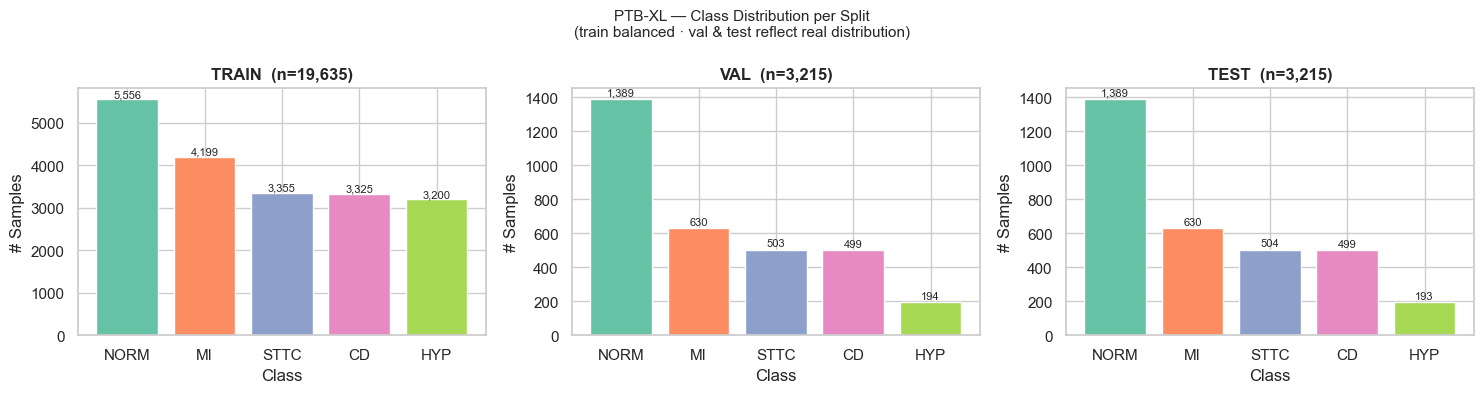


Figure saved → /Users/ayoub/work/MS-DS_ML_Projects/IOT/projet-embarque/dataset/processed/split_distribution.png


In [17]:
print("=" * 58)
print("  FINAL VERIFICATION")
print("=" * 58)

split_data = {}
for split in ("train", "val", "test"):
    X = np.load(PROC_DIR / split / "X.npy", mmap_mode="r")
    y = np.load(PROC_DIR / split / "y.npy", mmap_mode="r")
    split_data[split] = (X, y)
    dist = {LABEL_NAMES[i]: int((y == i).sum()) for i in range(N_CLASSES)}
    print(f"\n{split.upper()}")
    print(f"  X : {X.shape}  dtype={X.dtype}  min={X.min():.3f}  max={X.max():.3f}")
    print(f"  y : {y.shape}  dtype={y.dtype}  classes={sorted(set(y.tolist()))}")
    print(f"  Distribution: {dist}")

total = sum(len(v[1]) for v in split_data.values())
print()
print(f"Total samples across splits : {total:,}")
for split, (X, y) in split_data.items():
    print(f"  {split:<6} : {len(y):>6,}  ({100*len(y)/total:.1f}%)")

print()
print(f"class_weights.npy : {np.load(PROC_DIR / 'class_weights.npy')}")

# ── Visual check ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
palette   = sns.color_palette("Set2", N_CLASSES)

for ax, (split, (_, y)) in zip(axes, split_data.items()):
    counts_s = pd.Series(y).map(LABEL_NAMES).value_counts()
    order = list(SUPERCLASS_LABELS.keys())
    vals  = [counts_s.get(c, 0) for c in order]
    bars  = ax.bar(order, vals, color=palette, edgecolor="white")
    ax.set_title(f"{split.upper()}  (n={len(y):,})", fontweight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("# Samples")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 10,
                f"{v:,}", ha="center", va="bottom", fontsize=8)

plt.suptitle("PTB-XL — Class Distribution per Split\n"
             "(train balanced · val & test reflect real distribution)",
             fontsize=11)
plt.tight_layout()
plt.savefig(str(PROC_DIR / "split_distribution.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"\nFigure saved → {(PROC_DIR / 'split_distribution.png').resolve()}")